# Tutorial: Getting Started with Containers

This tutorial covers the basics of how to use containers to deploy software on the OSPool.

## Setup

1. Login to [osg-htc.org/notebooks](https://osg-htc.org/notebooks).
2. Launch the "Guest" notebook option.
3. Navigate to the directory `tutorial-containers`.
4. Open the notebook `tutorial-containers.ipynb`.
5. Follow the instructions in the notebook.

## Materials

* Slides: TBD
* Notebook: [tutorial-containers.ipynb](/tutorial-containers.ipynb)
* GitHub: [github.com/osg-htc/tutorial-containers](https://github.com/osg-htc/tutorial-containers.git)

## Disclaimer

The content of this training represents the practical, cumulative hands-on experience of someone who 

* does not have a background in computer science
* is not a professional programmer
* is not a developer of container technologies

As such, there may be inaccuracies in technical details and mental models of containers, their functionality, and their implementation.

# Quickstart: The Power of Containers

A short hands-on exercise demonstrating how containers can be useful.

Let's say that you need to use Python 3.10 for your research program.

First, check the version of Python available in the OSPool Notebook:

In [1]:
python3 --version

Python 3.13.7


As you can see, the OSPool Notebook service is using Python 3.13.
While there are many ways of deploying a custom Python environment, we're going to use a "container", since the lesson will apply to more than just Python programs.

First, let's "build" a container.
For now, just run the provided commands - we'll discuss what each one is doing later in the training.

In [2]:
apptainer build python310.sif docker://python:3.10

INFO:    Starting build...
INFO:    Fetching OCI image...
712.0KiB / 5.8MiB [====>-----------------------------------] 12 % 652.9 KiB/s 8s
216.8KiB / 64.6MiB [-------------------------------------] 0 % 198.8 KiB/s 5m31s
185.9KiB / 20.1MiB [-------------------------------------] 1 % 170.5 KiB/s 1m59s
99.8KiB / 225.1MiB [-------------------------------------] 0 % 91.5 KiB/s 41m57s
120.5KiB / 47.0MiB [-------------------------------------] 0 % 110.5 KiB/s 7m14s
2.8MiB / 5.8MiB [====================>-----------------------] 49 % 2.3 MiB/s 1s
1.4MiB / 64.6MiB [>------------------------------------------] 2 % 1.2 MiB/s 54s
1.3MiB / 20.1MiB [==>----------------------------------------] 6 % 1.0 MiB/s 17s
1.1MiB / 225.1MiB [---------------------------------------] 0 % 943.3 KiB/s 4m3s
1.0MiB / 47.0MiB [>----------------------------------------] 2 % 848.3 KiB/s 55s
4.7MiB / 5.8MiB [==================================>---------] 80 % 3.4 MiB/s 0s
3.0MiB / 64.6MiB [=>-------------------------------

(There may be a lot of lines due to the progress bars.)

When it is done, there is a new file `python310.sif`:

In [3]:
ls -lh python310.sif

-rwxr-xr-x 1 jovyan users 362M Feb  9 15:21 python310.sif


Now that you have the `.sif` file of the container, you can use it as an execution environment for commands and scripts.

Let's see what version of Python is available in this container:

In [4]:
apptainer exec python310.sif python3 --version

Python 3.10.19


It's Python 3.10!

Another thing to note is that this software environment is portable.
You could copy this `.sif` file to another Linux machine (that has Apptainer installed), run the same command, and you'll get the same output!

This example is overly simplified, and there are a lot more details and caveats involved, but..

The takeaway is: **Containers are portable, reproducible software environments that you control.**

# Core Concepts

A simplified mental model for working with containers

There are some **core concepts** that you should know to work with containers.
Under the hood, containers are a fairly complicated piece of technology. 
But like with driving a car, you don't need to know how the engine works in order to get around town.

We'll start with an analogy to "movies".

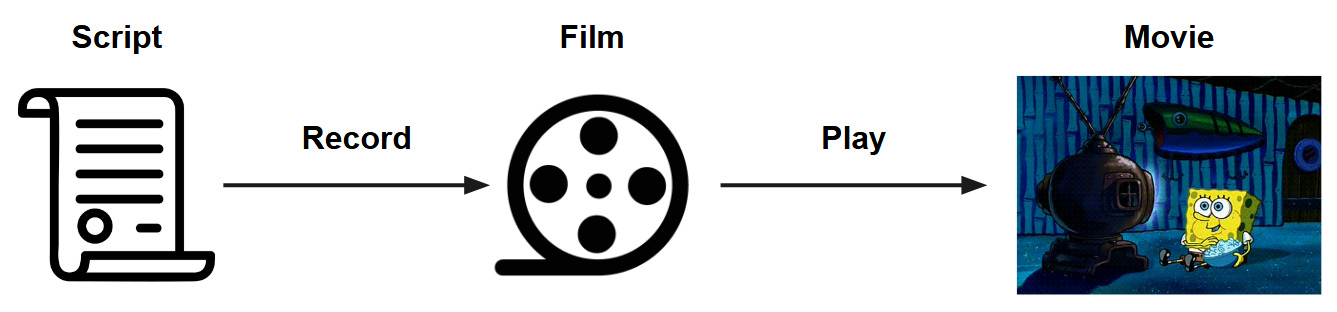

1. A **movie** is the sequence of images and sounds that you watch on the screen.
2. To watch a movie, you have to **run** or **play** it.
3. The **film** or other physical media stores the movie and is portable to other compatible devices.
4. To create a movie, you have to **build** or **record** the film.
   * If you want to make small changes to an existing movie, you can edit an existing film.
   * If you want to make major changes, you should record a new film.
5. A **script** is used to organize the events and scenes to be recorded on film for creating the movie.

This description of a movie is analogous to how containers work.

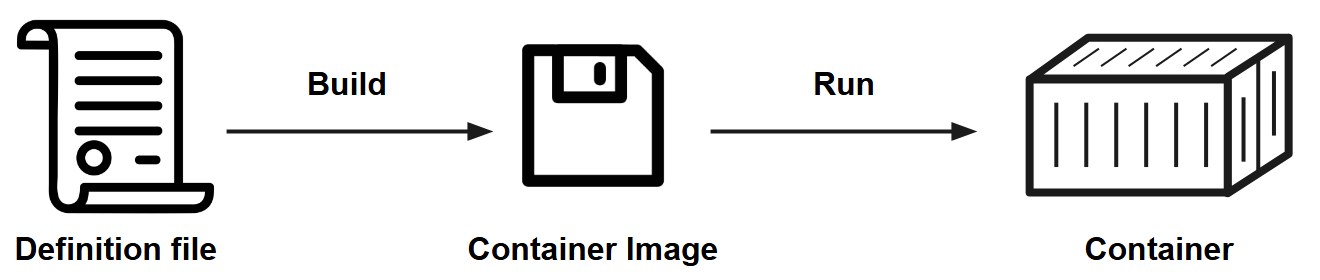

1. A **container** is the active environment that you can interact with.
2. To interact with a container, you must first **run** or **launch** it.
3. The **container image** stores the container and is portable to other compatible devices.
4. To create a container, you have to **build** the container image.
   * If you want to make small changes to an existing container image, you can "edit" it.
   * If you want to make major changes, you should build a new container image.
5. A **definition file** is used to organize the software and environment details for the build process.

> In the same way that the word **movie** can be used to refer to the physical media (the **film**, DVD, etc.) or the sequence of images on the screen,
> so too can the word **container** be used to refer to the **container image** or the actively running environment.

Some other things to note:

* You can easily build a new container on top of an existing container, adding software and functionality that was not present in the original container.
You could perhaps think of this as creating a custom "extended cut" version of a movie.
* The software installation commands are only executed when the container is built. The installation commands are not rerun each time you launch the container. This is just like how a movie is not re-recorded each time you press "play".
* Containers built on one type of machine (MacOS with ARM chip) may not work on other types of machines (Linux with x86_64 chip), like trying to play a Blu-ray disc in a regular DVD player. There are ways to convert between "formats" though.

**How does this relate to the quickstart?**

First, you built a new container image (`python310.sif`).
Then, you launched the container in order to run the version command.

> You didn't write a "definition file" in this case because you were effectively copying an existing container image (`docker://python:3.10`).



# Lifecycle for Deploying Software in Containers

An overview of the step-by-step process of working with containers.

The process of deploying software in containers follows this general sequence. 
More details for each step are provided in later sections.

1. **Identify the "main" software you want to deploy.**
2. **Check the instructions for installing the software you want to deploy.**
   * Are there additional programs required in order for the software to work?
   * Is there a "major" platform you can use to install the software (e.g., `pip`, `conda`, `cran`)
3. **Find a good "base" container image to use as a starting point**
   * A good rule is that the "base" container image should already include the most-difficult-to-install software that you need
   * **Note**: some developers publish official container images for their software!
4. **Write a definition file, containing the installation commands for the software you want**
5. **Build the container image**
   * There are commonly issues with this step! Make changes to the definition file that address the error message you get.
6. **Test that the software in the container image works as expected**
   * A "successful" build doesn't mean the software is working!
7. **Distribute the container image where it needs to go**
8. **Use the container image**

Once you have a working container (after step 6), then in principle you never have to repeat steps 1-6!
If you do want to make changes, the best action in terms of reproducibility is to go back to step 4 to edit the definition file and repeat the following steps.

**Deploying your software in a container is no more difficult than any other methods of deploying your software!**
Even if you don't use a container, you'll still need to learn how to install your software program, and installing software is hard, period.
By using a container, you also get:

* a reproducible environment, separate from the host operating system
* control over the libraries and other programs you want to install
* simple deployment, again separate from the host operating system

# Example: A More Realistic Python Container

A hands-on exercise for a practical example involving Python.

You are starting a new computational research project and have identified the "main" software that you want to deploy.

The program is a collection of scripts in a GitHub repository.
The README states that is requires `python` v3.10, as well as the Python packages `numpy` (v1.26) and `scipy`.
They provide some commands to run that *should* fulfill the requirements:

```
sudo apt-get install python3 python3-pip
pip install numpy scipy
```

For your own purposes, you also want to use the Python package `seaborn`. 

How should you proceed?

## A good starting point

Considering the software requirements, if you are able to get `python` set up, then you should be able to use the `pip` command to install additional Python packages.

**A good base container would come with `python` v3.10 already installed.**

A lot of mainstream softwares (and even niche softwares, depending on the developer) have official containers published on the internet for anyone to use.
In general, most of these containers are published on "DockerHub", which is kind of like "GitHub", but for container images.
Keep in mind, though, that anyone can publish containers on DockerHub!

When you search for containers on DockerHub, look for images with the labels `Docker Official Image`, `Verified Publisher`, or `Sponsored OSS`.
These will generally be safe to use, but like with anything on the internet, you should do some due diligence to make sure the publishers are legitimate. 

When you search DockerHub for `python`, you should see a result for a "Docker Official Image". 
Clicking on the result takes you to [this page](https://hub.docker.com/_/python), which lists a lot of information.
You can then look at the `Tags` tab for the particular version of the container you are interested in. 
In this case, if you search "3.10", you'll get 19 pages of results (!). 

**The TL;DR is that you want to use `docker://python:3.10` as the base image for your container.**

> Smaller, less "foundational" softwares will have much fewer results that are easier to look through.
> Once you've decided on a version, you want to look for the text `docker pull <reponame>/<imagename>:<tagname>`.
> You can then use the corresponding address `docker://<reponame>/<imagename>:<tagname>` in compatible container technologies to reference that container image.
>
> Because `python` is an official repository, the `<reponame>` and `<imagename>` are combined into one.

## Writing the definition file

The exact format of the definition file depends on the container technology that you are using.

Today, we are focusing on the [Apptainer](https://apptainer.org/) container program, which is open source and designed for shared computing systems.
The tech industry has largely adopted [Docker](https://www.docker.com/) (which is where the "Docker" in "DockerHub" comes from), but it is a commercial technology intended for enterprise systems and personal computers. 
Conveniently, you can convert a container image from the Docker format to the Apptainer format (it is more difficult to do the reverse).

A simple Apptainer definition file has the following format:

```
Bootstrap: docker
From: <reponame>/<imagename>:<tagname>

%post
    # software installation commands
```

Here is what each line is doing:

1. `Bootstrap: docker` - this tells Apptainer to use a Docker container as a base image.
2. `From:` - this tells Apptainer the address of the container image. When the `Bootstrap` is set to `docker`, this corresponds to the address on DockerHub, by default.
3. Empty line - purely for aesthetics
4. `%post` - this tells Apptainer that the following lines are the commands to run during the container "build".
5. A comment - this will be ignored. Also note that the leading indent is optional.

> There are more sections (denoted by a leading `%`) for triggering different features, but this simple example works for 90% of users.
> See the [Apptainer documentation](https://apptainer.org/docs/user/latest/definition_files.html) for more information.

**Create a new file called `my-container.def` with the following contents:**

```
Bootstrap: docker
From: python:3.10

%post
    python3 -m pip install numpy==1.26 scipy seaborn
```

Make sure to save the file!

Run the following command and confirm the contents are the same:

In [9]:
cat my-container.def

Bootstrap: docker
From: python:3.10

%post
    python3 -m pip install numpy==1.26 scipy seaborn


## Build the container

At this point, you've written the script for the movie.
Now you need to record it to film.

To build an Apptainer container, you use the command

```
apptainer build <desired_name> <definition_file>
```

The filename you desire for the container image is the first argument, while the instructions for building the container image (the definition file) is the second argument.

> For historic reasons, the Apptainer image name traditionally uses the extension `.sif`, but that is not technically required.

For our example, that means the command to run is

```
apptainer build my-container.sif my-container.def
```

Build the container by running following command:

In [10]:
apptainer build my-container.sif my-container.def

INFO:    User not listed in /etc/subuid, trying root-mapped namespace
INFO:    The %post section will be run under the fakeroot command
INFO:    Starting build...
INFO:    Fetching OCI image...
0.0b / 64.6MiB [------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 64.6MiB [------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 5.8MiB [-------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 24.4MiB [------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 20.1MiB [------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 225.1MiB [-----------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 47.0MiB [------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 64.6MiB [------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 5.8MiB [-------------------------------------------------] 0 % 0.0 b/s 0s
0.0b / 24.4MiB [------------------------------------------------] 0 % 0.0 b/s

You will say a lot of output here, mostly because progress bars don't render "normally" in a Jupyter notebook.

First, Apptainer downloads the base container from DockerHub.
This involves multiple files and extractions - you don't need to worry much about what is happening here.

Note the `INFO: Running post scriptlet` line. 
This is where Apptainer starts running the commands that you provided in the `%post` section of the definition file.
If you are familiar with `pip install` commands, the output is the almost exactly the same as usual!

> When building a container, you can ignore the warning from pip about running as 'root'.
> You should totally heed that warning if you aren't building a container!

Finally, once the `%post` commands have all run (typically "successfully"), Apptainer records the results as a `SIF` formatted file.
The process is complete once you see `Build complete`.

Confirm that the container image has been created by running:

In [11]:
file my-container.sif

my-container.sif: a run-singularity script executable (binary data)


## Test/use the container

It's always good practice to review the final product. 

You can execute commands one at a time using the `apptainer exec` command, which is what we used in the Quickstart section.
The syntax is

```
apptainer exec <image_name> <command_to_run>
```

In general, if you can "import" a package or print the program's help text, that means the program has been successfully installed.
(But whether it does what you want is a separate question!)

Run the following command to check that the desired packages have been installed:

In [12]:
apptainer exec my-container.sif python3 -c 'import numpy, scipy, seaborn; print("numpy =",numpy.__version__); print("scipy =",scipy.__version__); print("seaborn =",seaborn.__version__)'

numpy = 1.26.0
scipy = 1.15.3
seaborn = 0.13.2


You should see 

```
numpy = 1.26.0
scipy = 1.15.3
seaborn = 0.13.2
```

For more involved tests or commands, it's better to write a short script with the commands you want to use and then execute them inside the container.

To see this in practice, create a file called `python-test.py` with the following contents:

```python
import numpy, scipy, seaborn, sys

print(f"""
python = {'.'.join(map(str, sys.version_info))}
numpy = {numpy.__version__}
scipy = {scipy.__version__}
seaborn = {seaborn.__version__}
""")
```

(we've also added a line to check the version of Python)

Then run the following command:

In [16]:
apptainer exec my-container.sif python3 python-test.py


numpy = 1.26.0
scipy = 1.15.3
seaborn = 0.13.2



To run commands in the container environment interactively, you can use the `shell` command:

```
apptainer shell my-container.sif
```

This doesn't work well in Jupyter notebooks, however.
To try it, first open a new "terminal" tab in the Jupyter notebook.
Then run the `apptainer shell my-container.sif` command.

The commands you run will be executed in the container environment.
When you are done, enter

```
exit
```

to exit the interactive shell mode.

***Do not evaluate any notebook cells while the `apptainer shell` is active!***
Jupyter and `apptainer shell` don't play well together and you may get weird errors otherwise!

## Putting scripts in the container

In the initial scenario, we proposed that you are a researcher trying to use some scripts in a GitHub repository.
How should you get those scripts into the container image?

First, you have to answer this question: when should the scripts be placed inside the container image?

1. During the build phase?
2. During the execution phase?

### Adding scripts during the build phase

Option 1 is fine for "mature" programs - that is, something that you don't plan to modify after the build phase is complete and the container image has been created. 
Maybe you'll make changes, but you can plan on repeating the build phase to create a new container image in that case.

To add files to the container build, you can use the `%files` section of the definition file, as described [here](https://apptainer.org/docs/user/latest/definition_files.html#files). (This is specific to Apptainer, but other container technologies have an analogous method; the specific syntax varies.)

If the files are publically available, you can also just do a `git clone`, `wget`, or some other download command to fetch the files during the build phase.

### Adding scripts during the execution phase

Option 2 is best for "developing" programs - that is, something that you are actively developing. Because you are frequently making changes to the scripts, you want to skip the build phase as much as possible.

* If you are manually launching the container, you should check out the "Appendix A: Containers and the filesystem" section at the end of this document.
* If you are submitting jobs to the OSPool, scripts included in the `transfer_input_files` line of your submit file will be automatically added to the container at the run time of the job.

# Containers on the OSPool

Distributed computing with containers in mind.

The OSPool is a distributed computing resource that is available for free to all U.S.-based researchers.

* [Overview of the OSPool](https://osg-htc.org/services/ospool)
* [Getting started on the OSPool](https://portal.osg-htc.org/documentation/overview/account_setup/is-it-for-you/)

Since the computer resources are geographically distributed across the U.S., data distribution can be a challenge.
Containers and other re-usable data can be "cached" in various places using the Open Science Data Federation (OSDF).
All OSPool users have a personal directory accessible via the OSDF.
Non-OSPool users can also access public data in the OSDF and can work with the team to set up authenticated access.

* [Overview of the OSDF](https://osg-htc.org/services/osdf)
* [Public data in the OSDF](https://osg-htc.org/services/osdf/data)
* [OSDF documentation for OSPool users](https://portal.osg-htc.org/documentation/htc_workloads/managing_data/osdf/)
* [OSDF documentation for non-OSPool users](https://docs.osdf.osg-htc.org/)

The software HTCondor is used to run the OSPool, and HTCondor comes with built-in container support.
In principle, all you need to do is add the following line to your submit file:

```
container_image = osdf:///location/of/container/image.sif
```

The use of Apptainer images is well supported on the OSPool.
While HTCondor has good support for Docker images as well, most computing capacity accessible via the OSPool does not use Docker.

## Simple Python Job

We've provided some example "submit files" for describing an HTCondor job. 

The first example does not use a container:

```
log = no-container.log

transfer_input_files = python-test.py

shell = python3 python-test.py
output = no-container.out
error = no-container.err

request_cpus = 1
request_memory = 1GB
request_disk = 1GB

queue 1
```


In [95]:
cat no-container.sub

log = no-container.log

transfer_input_files = python-test.py

shell = python3 python-test.py
output = no-container.out
error = no-container.err

request_cpus = 1
request_memory = 1GB
request_disk = 1GB

queue 1


Things to note:

* The `shell` line tells HTCondor what command we want the job to run; in this case, it's executing the `python-test.py` that we made earlier using `python3`.
* We have to explicitly state any input files that need to be transferred to the worker machine ("execution point")
* We specify `output` and `error` files, which will capture what is normally printed to the screen
* We requested the amount of resources the job needs in order to execute
* We specified a number of jobs to run

There are a lot more possible options to include, but those are topics for other trainings.

You can submit this test job by running `condor_submit <submit_file>.sub`.

In [96]:
condor_submit no-container.sub

Submitting job(s).
1 job(s) submitted to cluster 2.


You can check the status of your jobs by running the command `condor_q`. 
This gives a snapshot of **currently active or pending** jobs.
If the job disappears from this list, then it has completed or you have removed it.

In [97]:
condor_q



-- Schedd: jovyan@jupyter-aowen4-wisc-edu---0bf5e8be : <10.129.189.155:9618?... @ 02/09/26 22:35:58
OWNER  BATCH_NAME    SUBMITTED   DONE   RUN    IDLE  TOTAL JOB_IDS
jovyan ID: 2        2/9  22:35      _      _      1      1 2.0

Total for query: 1 jobs; 0 completed, 0 removed, 1 idle, 0 running, 0 held, 0 suspended 
Total for all users: 1 jobs; 0 completed, 0 removed, 1 idle, 0 running, 0 held, 0 suspended



> If using a normal terminal (i.e., not a Jupyter Notebook), then you can use the command `condor_watch_q` to monitor the live progress of your jobs.

When completed, you should see the new files `no-container.out` and `no-container.err`. (The `no-container.log` file is created immediately on submission and is HTCondor's record of its management of your job.)

Let's see what they contain:

In [98]:
cat no-container.out


numpy = 2.3.3
scipy = 1.16.2
seaborn = 0.13.2



In [99]:
cat no-container.err

> If you are using the "Guest" option of the OSPool Notebook, then the result will be the same as if you had directly ran the command `python3 python-test.py`.
> If you are using the "Full Account" option of the OSPool Notebook, then the result will reflect whatever happens to be installed (or not installed!) on the contributed execution point.

As before, we want to ensure that our desired packages are installed and have the right versions.

In the second example, we've added the `container_image` line to specify the Apptainer image we want to use.
(We also changed the names of the files we are generating to match the name of the submit file.)

```
log = with-container.log

container_image = my-container.sif

transfer_input_files = python-test.py

shell = python3 python-test.py
output = with-container.out
error = with-container.err

request_cpus = 1
request_memory = 1GB
request_disk = 1GB

queue 1
```

> NOTE: If you are **not** using the "Guest" option of the OSPool Notebook, you should not submit more than 1 or 2 jobs using this approach!
> You should instead follow the instructions for using the OSDF with containers, described [here](https://portal.osg-htc.org/documentation/htc_workloads/managing_data/osdf/).

In [100]:
cat with-container.sub

log = with-container.log

container_image = my-container.sif

transfer_input_files = python-test.py

shell = python3 python-test.py
output = with-container.out
error = with-container.err

request_cpus = 1
request_memory = 1GB
request_disk = 1GB

queue 1


Like before, submit this job using `condor_submit`:

In [101]:
condor_submit with-container.sub

Submitting job(s).
1 job(s) submitted to cluster 3.


When complete, check the contents of the new files:

In [102]:
cat with-container.out


numpy = 1.26.0
scipy = 1.15.3
seaborn = 0.13.2



In [103]:
cat with-container.err

You should see that the version of packages matches what you get when you run the python script directly in the container:

In [106]:
apptainer exec my-container.sif python3 python-test.py


python = 3.10.19.final.0
numpy = 1.26.0
scipy = 1.15.3
seaborn = 0.13.2



# Appendix A: Containers and the filesystem

Things start to get complicated when input and output files are involved.

When a container is launched, it is separated from the rest of the computer.
This usually includes the filesystem.
If you try to access a "higher" level directory from inside of the container, you may "see" a different set of files.

Apptainer has default behavior to make a bridge between the host system and the container environment.
Understanding that bridge will help us understand how we can make changes to the way the container interacts with the host.

### Accessing files from inside the container

Let's start by running this command on the host and inside of the container:

In [54]:
echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"

**PWD=/home/jovyan/container-training**
create_directory_and_file.sh
filesystem-test.sh
my-container.def
my-container.sif
python-test.py
python310.sif
tutorial-containers.ipynb

**HOME=/home/jovyan**
container-training
pelican-training-client
tutorial-fastqc
tutorial-minimap2
tutorial-osdf-noaa
tutorial-r-noaa
tutorial-wordfreq
work


The command shows the current directory (`PWD`), its contents, the home directory (`HOME`), and its contents.

Now let's run it inside of the container:

In [55]:
apptainer exec my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

**PWD=/home/jovyan/container-training**
create_directory_and_file.sh
filesystem-test.sh
my-container.def
my-container.sif
python-test.py
python310.sif
tutorial-containers.ipynb

**HOME=/home/jovyan**
container-training
pelican-training-client
tutorial-fastqc
tutorial-minimap2
tutorial-osdf-noaa
tutorial-r-noaa
tutorial-wordfreq
work


The two executions have the same output - this is because Apptainer's default "bridge" is in place to make it easier to work with the container environment.

> The `bash -c ''` part is necessary in order to make sure the shell variables `$PWD` and `$HOME` are evaulated inside of the container environment, and not in the host environment.

We can disable Apptainer's default "bridge" by using the `--contain` option.
Let's see what happens this time:

In [56]:
apptainer exec --contain my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

**PWD=/home/jovyan**


**HOME=/home/jovyan**



Some things have changed: 

* the current directory (`PWD`) is now the same as the home directory
* the home directory (`HOME`) is empty (!)

So (among other things), Apptainer's defaults make it so that the current directory (and its contents) on the host are accessible inside of the container environment, and that the home directory (and its contents) on the host is as well.

We can manually recreate the bridge. To do so, we'll need to use the `--bind` and `--cwd` options:

* `--bind <location_in_host>:<location_in_container>` - this option maps a directory on the host system to a location of your choice inside of the container.
* `--cwd <location_in_container>` - this options says where inside the container the command should be executed.

First, let's add in the current directory. We can use `--bind $PWD:$PWD` to do so (because when we run the `apptainer exec` command, the `PWD` environment variable is set to the host's value).
We'll also need to use `--cwd` to change the value of `PWD` inside of the container:

In [64]:
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

**PWD=/home/jovyan/container-training**
create_directory_and_file.sh
filesystem-test.sh
my-container.def
my-container.sif
python-test.py
python310.sif
tutorial-containers.ipynb

**HOME=/home/jovyan**
container-training


Now we see what we expected to see for the current directory.

Note that we see **only** the `container-training` directory inside of the home directory - that is because that is the only part of the host filesystem that we told Apptainer to make available inside the container.

If we want to see all of the host home directory inside the container, we can bind that in as well:

In [65]:
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD --bind $HOME:$HOME my-container.sif bash -c 'echo -e "**PWD=${PWD}**\n$(ls $PWD)\n\n**HOME=$HOME**\n$(ls $HOME)"'

**PWD=/home/jovyan/container-training**
create_directory_and_file.sh
filesystem-test.sh
my-container.def
my-container.sif
python-test.py
python310.sif
tutorial-containers.ipynb

**HOME=/home/jovyan**
container-training
pelican-training-client
tutorial-fastqc
tutorial-minimap2
tutorial-osdf-noaa
tutorial-r-noaa
tutorial-wordfreq
work


In this case, we again see the contents of the home directory.

> Since the `PWD` directory is inside of the `HOME` directory tree, we technically only needed to use one `--bind`  option: `--bind $HOME:$HOME`.

While in practice this combination of `--contain` and `--bind` effectively cancel each other out, the point is that **with the `--bind` option you can specify what part of the host filesystem your container has access to**.

### "Saving" changes

IMPORTANTLY: **only files created in a "mounted" (`--bind`) directory will be kept after the container stops running!!**

To demonstrate this, we'll first make a script as follows:

In [78]:
cat << EOF > create_directory_and_file.sh
mkdir -p ~/test_directory
touch ~/test_directory/example.txt
echo "Created \$(ls ~/test_directory/example.txt)"
EOF

chmod +x create_directory_and_file.sh

This script will create a new directory `test_directory` and create a new file in that directory, called `example.txt`, and then confirm that the file exists at the time of the script execution. 

First, let's execute try executing this script in the container using the `--contain` option but no `--bind` mounting:

In [79]:
apptainer exec --contain my-container.sif bash create_directory_and_file.sh

/usr/bin/bash: create_directory_and_file.sh: No such file or directory


: 127

This fails, because inside of the container there is no such script.

We need to add in the `PWD` binding we did earlier:

In [80]:
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD my-container.sif bash create_directory_and_file.sh

Created /home/jovyan/test_directory/example.txt


That appears to have worked as expected.

Let's check if it exists after the container has stopped running:

In [82]:
ls ~/test_directory/example.txt
ls -ld ~/test_directory

ls: cannot access '/home/jovyan/test_directory/example.txt': No such file or directory
ls: cannot access '/home/jovyan/test_directory': No such file or directory


: 2

Nope!

If we want the changes to persist, we'll need to either mount the parent directory (`HOME`) into the container, or else copy the files to a part that is mounted.
Either of these should work:

```bash
apptainer exec --contain --bind $HOME:$HOME --cwd $PWD my-container.sif bash create_directory_and_file.sh
# OR
apptainer exec --contain --bind $PWD:$PWD --cwd $PWD my-container.sif bash -c 'bash create_directory_and_file.sh && cp ~/test_directory/example.txt ./'
```

The first example is probably the "simplest" conceptually, but it does give the container and the script access to your entire home directory (!). 
The second example protects your home directory, but is more complex.

The best approach to address this situation, in practice, is to modify the main script (here, `create_directory_and_file.sh`) to operate at or below the execution directory.
That is, instead of `mkdir -p ~/test_directory` the script should do `mkdir -p ./test_directory`. 

### Containers are immutable

Another important item to note is that **most locations "in" the container image are read-only**.

For example, let's try to create a file in the root directory:

In [88]:
apptainer exec --contain my-container.sif bash -c 'touch /my-new-file.txt'

touch: cannot touch '/my-new-file.txt': Read-only file system


: 1

In [89]:
apptainer exec my-container.sif bash -c 'touch /my-new-file.txt'

touch: cannot touch '/my-new-file.txt': Read-only file system


: 1

The root directory (`/`) and some of it's immediate subdirectories cannot by `--bind` mounted into the container - these directories are needed by the container in order to function!
And depending on how your administrator configured the Apptainer installation, there may be other locations that this applies to.

Sometimes, a program will try to write files into the root directory. There are generally two cases:

1. The program is trying to use a default location that evaulates to a read-only location.
2. The program is trying to use a specific absolute path.

The most common occurence of (1) is that during installation, the program used the value of `HOME` to be the root directory (`/`). This problem can be usually resolved by including a `export HOME=<value>` statement with `<value>` replaced by a mounted location in the container. Some programs may have more specific settings to manipulate, such as a "cache" location or some other setting. Digging into the documentation usually reveals the setting you should change.

There are two main causes of (2): (a) your script uses absolute paths or (b) you are using a container specifically written for Docker.

* (a): Often researchers who write their own programs start on their personal computer. To stay organized, they have some code that says all outputs should go into a directory like `/User/Documents/Research/Project3/outputs`, while maybe the script itself lives in `/User/Programs/my_code.py`. To work in containers (and shared computing systems), the researcher should modify their code to work with relative paths instead.
* (b) The "normal" installation of Docker does allow some writing in the root directory (`/`), so some developers will use paths like `/data` or `/app` for writing temporary files. Sometimes the "official" container you are using follows this paradigm. You may be able to modify the container to work around this issue, but it may be easier to build a new container where you manually install the software yourself.

# Appendix B: Tips for Building Containers

Software installation is hard, regardless of whether or not it's in a container.